In [10]:
import pandas as pd

In [30]:
import matplotlib.pyplot as plt

In [15]:
df = pd.read_excel('board2.xlsx')
df['Average'] = df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication,Average
0,S1,Male,Instrumentation,Luzon,58,89,75,78,75.00
1,S2,Female,Communication,Mindanao,52,75,90,52,67.25
2,S3,Female,Instrumentation,Mindanao,83,74,77,57,72.75
3,S4,Male,Instrumentation,Visayas,65,58,91,68,70.50
4,S5,Male,Communication,Luzon,59,86,43,88,69.00
5,S6,Female,Microelectronics,Visayas,88,45,86,83,75.50
6,S7,Female,Instrumentation,Luzon,66,60,60,48,58.50
7,S8,Male,Instrumentation,Luzon,49,81,64,53,61.75
8,S9,Male,Instrumentation,Luzon,50,36,63,42,47.75
9,S10,Male,Microelectronics,Mindanao,80,84,61,44,67.25


In [19]:
VisComm = df.loc[(df['Hometown']=='Visayas')&(df['Track']=='Communication'), ['Name', 'Gender', 'Math', 'Electronics','Average']].reset_index()
VisComm

,index,Name,Gender,Math,Electronics,Average
0,10,S11,Female,48,56,54.75
1,11,S12,Male,89,67,76.00
2,17,S18,Male,81,40,63.50
3,21,S22,Female,64,39,62.50
4,27,S28,Male,85,53,67.75


In [20]:
len(VisComm)

5

In [23]:
VisFemale = df.loc[(df['Hometown']=='Visayas')&(df['Gender']=='Female'), ['Name', 'Track', 'GEAS', 'Electronics','Average']].reset_index()
VisFemale

,index,Name,Track,GEAS,Electronics,Average
0,5,S6,Microelectronics,86,45,75.50
1,10,S11,Communication,48,56,54.75
2,20,S21,Microelectronics,68,51,68.50
3,21,S22,Communication,89,39,62.50
4,23,S24,Microelectronics,60,45,57.75
5,25,S26,Instrumentation,83,47,65.75


In [24]:
VisFemaleOverSixty = VisFemale.loc[(VisFemale['Average']>60)].reset_index()
VisFemaleOverSixty

,level_0,index,Name,Track,GEAS,Electronics,Average
0,0,5,S6,Microelectronics,86,45,75.50
1,2,20,S21,Microelectronics,68,51,68.50
2,3,21,S22,Communication,89,39,62.50
3,5,25,S26,Instrumentation,83,47,65.75


In [26]:
TrackAverage = df.groupby('Track')['Average'].mean().reset_index()
TrackAverage

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


In [28]:
GenderAverage = df.groupby('Gender')['Average'].mean().reset_index()
GenderAverage

,Gender,Average
0,Female,66.616667
1,Male,67.183333


In [27]:
HometownAverage = df.groupby('Hometown')['Average'].mean().reset_index()
HometownAverage

,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


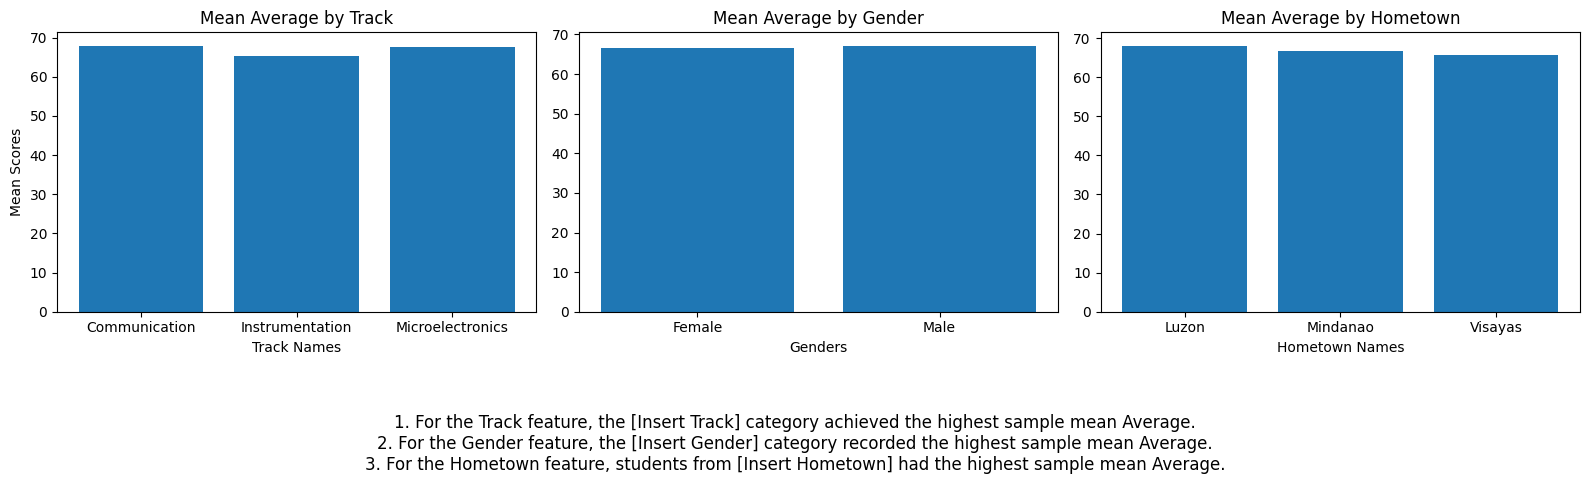

In [42]:
fig, axes = plt.subplots(1,3,figsize=(16,5))

axes[0].bar(TrackAverage['Track'], TrackAverage['Average'])
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track Names')
axes[0].set_ylabel('Mean Scores')

axes[1].bar(GenderAverage['Gender'], GenderAverage['Average'])
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Genders')

axes[2].bar(HometownAverage['Hometown'], HometownAverage['Average'])
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown Names')

plt.tight_layout(rect=[0, 0.25, 1, 1])

findings = (
    "1. For the Track feature, the [Insert Track] category achieved the highest sample mean Average.\n"
    "2. For the Gender feature, the [Insert Gender] category recorded the highest sample mean Average.\n"
    "3. For the Hometown feature, students from [Insert Hometown] had the highest sample mean Average."
)

fig.text(0.5, 0.05, findings, ha='center', fontsize=12)

plt.show()